In [1]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import os 
from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots
import pandas as pd

from helpers import *

## Group all RD results

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path

H, W = 120, 40
diags        = ["sxr", "dmpx", "pilatus", "pilatus_rd_alpha_by_camera", "pilatus_rdcorrect_ula1e6"]
noise_levels = {}
noise_levels["sxr"] = [0.05, 0.25, 0.5]
noise_levels["dmpx"] = [0.1, 0.5, 1.0]
noise_levels["pilatus"] = [0.07, 0.35, 0.7]
noise_levels["pilatus_rd_alpha_by_camera"] = [0.07, 0.35, 0.7]
noise_levels["pilatus_rdcorrect_ula1e6"] = [0.07, 0.35, 0.7]
procedures   = ["true", "false"]
num_samples  = 1000

csv_dir_out = Path("metrics_csv_phantom_analysis_rd")
csv_dir_out.mkdir(exist_ok=True)

for diag in diags:
    print(f"\n{'='*60}")
    print(f"Processing diagnostic: {diag}")
    print(f"{'='*60}")

    if diag == "pilatus_rd_alpha_by_camera":
        csv_dir_in = Path(f"metrics_csv_phantom_analysis_pilatus_rd_alpha_by_camera")
    elif diag == "pilatus_rdcorrect_ula1e6":
        csv_dir_in = Path(f"metrics_csv_phantom_analysis_pilatus_rd_ula_more_samples")
    else:
        csv_dir_in = Path(f"metrics_csv_phantom_analysis_{diag}_rd")

    # --------------------------------------------------------------------------
    # 1. Merge chunked CSVs into one CSV per (noise_level, procedure)
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            if diag == "pilatus_rd_alpha_by_camera" or diag == "pilatus_rdcorrect_ula1e6":
                chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_pilatus_chunk*_{sigma}_{proc_str}.csv"))
            else:
                chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_{diag}_chunk*_{sigma}_{proc_str}.csv"))
            if not chunk_csvs:
                print(f"No chunks found for sigma={sigma}, procedure={proc_str}, skipping...")
                continue

            df = pd.concat([pd.read_csv(f) for f in chunk_csvs], ignore_index=True)
            df = df.sort_values("sample_idx").reset_index(drop=True)

            out_csv = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
            df.to_csv(out_csv, index=False)
            print(f"Saved {out_csv}  ({len(df)} rows)")

    # --------------------------------------------------------------------------
    # 2. Merge all per-combination CSVs into one global dataframe per diag
    # --------------------------------------------------------------------------
    all_dfs = []
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            csv_path = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
            if csv_path.exists():
                all_dfs.append(pd.read_csv(csv_path))

    if all_dfs:
        df_all = pd.concat(all_dfs, ignore_index=True)
        df_all = df_all.sort_values(["sigma_y_tomo", "procedure", "sample_idx"]).reset_index(drop=True)
        df_all.to_csv(csv_dir_out / f"metrics_rd_{diag}_all.csv", index=False)
        print(f"\nSaved global CSV for {diag} with {len(df_all)} rows")
        print(df_all.describe()[["psnr_map", "ssim_map", "mse_map", "psnr_mean", "ssim_mean", "mse_mean"]])

    # --------------------------------------------------------------------------
    # 3. Stack per-sample .npy files into (1000, H, W) arrays
    # --------------------------------------------------------------------------
    for sigma in noise_levels[diag]:
        for proc_str in procedures:
            maps  = np.zeros((num_samples, H, W), dtype=np.float32)
            means = np.zeros((num_samples, H, W), dtype=np.float32)
            stds  = np.zeros((num_samples, H, W), dtype=np.float32)

            missing = []
            for idx in range(num_samples):
                if diag == "pilatus_rd_alpha_by_camera" or diag == "pilatus_rdcorrect_ula1e6":
                    npy_path = csv_dir_in / f"results_pilatus_{sigma}_{proc_str}_{idx}.npy"
                else:
                    npy_path = csv_dir_in / f"results_{diag}_{sigma}_{proc_str}_{idx}.npy"
                if not npy_path.exists():
                    missing.append(idx)
                    continue
                data = np.load(npy_path, allow_pickle=True).item()
                maps[idx]  = data["im_MAP"]
                means[idx] = data["mean"]
                stds[idx]  = data["std"]

            if missing:
                print(f"WARNING: {len(missing)} missing .npy files for "
                      f"{diag}, sigma={sigma}, proc={proc_str}: indices {missing}")

            np.save(csv_dir_out / f"maps_{diag}_{sigma}_{proc_str}.npy",       maps)
            np.save(csv_dir_out / f"post_means_{diag}_{sigma}_{proc_str}.npy", means)
            np.save(csv_dir_out / f"post_stds_{diag}_{sigma}_{proc_str}.npy",  stds)
            print(f"Saved stacked arrays for {diag}, sigma={sigma}, procedure={proc_str}  "
                  f"— shape {maps.shape}")


Processing diagnostic: sxr
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.05_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.25_false.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_true.csv  (1000 rows)
Saved metrics_csv_phantom_analysis_rd/metrics_rd_sxr_0.5_false.csv  (1000 rows)

Saved global CSV for sxr with 6000 rows
          psnr_map     ssim_map      mse_map    psnr_mean    ssim_mean  \
count  6000.000000  6000.000000  6000.000000  6000.000000  6000.000000   
mean     34.012382     0.944458   100.840520    34.094567     0.955626   
std       4.159157     0.037805   275.099102     4.294155     0.033684   
min      20.527901     0.742731     0.000035    22.910131     0.775722   
25%      30.956578     0.922874     0.000371    30.829312     0.937197   
50%   

In [3]:
# import numpy as np
# import pandas as pd
# from pathlib import Path

# H, W = 120, 40
# diag = "sxr"
# csv_dir_in  = Path("metrics_csv_phantom_analysis_sxr_rd")
# csv_dir_out = Path("metrics_csv_phantom_analysis_rd")
# csv_dir_out.mkdir(exist_ok=True)

# noise_levels = [0.05, 0.25, 0.5]
# procedures   = ["true", "false"]
# num_samples  = 1000

# # --------------------------------------------------------------------------
# # 1. Merge chunked CSVs into one CSV per (noise_level, procedure)
# # --------------------------------------------------------------------------
# for sigma in noise_levels:
#     for proc_str in procedures:
#         chunk_csvs = sorted(csv_dir_in.glob(f"metrics_rd_{diag}_chunk*_{sigma}_{proc_str}.csv"))
#         if not chunk_csvs:
#             print(f"No chunks found for sigma={sigma}, procedure={proc_str}, skipping...")
#             continue

#         df = pd.concat([pd.read_csv(f) for f in chunk_csvs], ignore_index=True)
#         df = df.sort_values("sample_idx").reset_index(drop=True)

#         out_csv = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
#         df.to_csv(out_csv, index=False)
#         print(f"Saved {out_csv}  ({len(df)} rows)")

# # --------------------------------------------------------------------------
# # 2. Merge all per-combination CSVs into one global dataframe
# # --------------------------------------------------------------------------
# all_dfs = []
# for sigma in noise_levels:
#     for proc_str in procedures:
#         csv_path = csv_dir_out / f"metrics_rd_{diag}_{sigma}_{proc_str}.csv"
#         if csv_path.exists():
#             all_dfs.append(pd.read_csv(csv_path))

# df_all = pd.concat(all_dfs, ignore_index=True)
# df_all = df_all.sort_values(["sigma_y_tomo", "procedure", "sample_idx"]).reset_index(drop=True)
# df_all.to_csv(csv_dir_out / f"metrics_rd_{diag}_all.csv", index=False)
# print(f"\nSaved global CSV with {len(df_all)} rows")
# print(df_all.describe()[["psnr_map", "ssim_map", "mse_map", "psnr_mean", "ssim_mean", "mse_mean"]])

# # --------------------------------------------------------------------------
# # 3. Stack per-sample .npy files into (1000, H, W) arrays
# # --------------------------------------------------------------------------
# for sigma in noise_levels:
#     for proc_str in procedures:
#         maps  = np.zeros((num_samples, H, W), dtype=np.float32)
#         means = np.zeros((num_samples, H, W), dtype=np.float32)
#         stds  = np.zeros((num_samples, H, W), dtype=np.float32)

#         missing = []
#         for idx in range(num_samples):
#             npy_path = csv_dir_in / f"results_{diag}_{sigma}_{proc_str}_{idx}.npy"
#             if not npy_path.exists():
#                 missing.append(idx)
#                 continue
#             data = np.load(npy_path, allow_pickle=True).item()
#             maps[idx]  = data["im_MAP"]
#             means[idx] = data["mean"]
#             stds[idx]  = data["std"]

#         if missing:
#             print(f"WARNING: {len(missing)} missing .npy files for "
#                   f"sigma={sigma}, proc={proc_str}: indices {missing}")

#         np.save(csv_dir_out / f"maps_{diag}_{sigma}_{proc_str}.npy",       maps)
#         np.save(csv_dir_out / f"post_means_{diag}_{sigma}_{proc_str}.npy", means)
#         np.save(csv_dir_out / f"post_stds_{diag}_{sigma}_{proc_str}.npy",  stds)
#         print(f"Saved stacked arrays for sigma={sigma}, procedure={proc_str}  "
#               f"— shape {maps.shape}")

## SXR metrics

In [4]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.05, 0.25, 0.5]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_sxr_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_sxr_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.05
MSE (MAP): 0.000258 +- 0.0002
SSIM (MAP): 0.967262 +- 0.0210
PSNR (MAP): 36.945454 +- 3.2094
MSE (Mean): 0.000260 +- 0.0003
SSIM (Mean): 0.973939 +- 0.0188
PSNR (Mean): 37.127442 +- 3.4533
Noise level: 0.25
MSE (MAP): 0.000568 +- 0.0005
SSIM (MAP): 0.942405 +- 0.0336
PSNR (MAP): 33.643585 +- 3.4984
MSE (Mean): 0.000540 +- 0.0004
SSIM (Mean): 0.955193 +- 0.0295
PSNR (Mean): 33.856786 +- 3.5438
Noise level: 0.5
MSE (MAP): 0.000960 +- 0.0008
SSIM (MAP): 0.923554 +- 0.0412
PSNR (MAP): 31.412259 +- 3.6149
MSE (Mean): 0.001017 +- 0.0008
SSIM (Mean): 0.934400 +- 0.0411
PSNR (Mean): 31.095344 +- 3.5922


Noise level: 0.05, procedure=True
MSE (MAP): 79.483011 +- 117.7957
SSIM (MAP): 0.968768 +- 0.0189
PSNR (MAP): 37.244024 +- 3.0742
MSE (Mean): 80.680756 +- 125.2453
SSIM (Mean): 0.975333 +- 0.0169
PSNR (Mean): 37.374745 +- 3.3615
Noise level: 0.25, procedure=True
MSE (MAP): 196.314935 +- 316.4073
SSIM (MAP): 0.942129 +- 0.0335
PSNR (MAP): 33.522888 +- 3.4860
MSE (Mean): 181.68

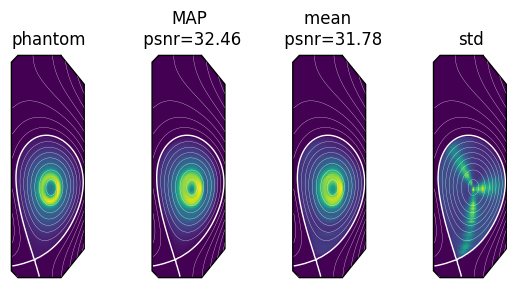

In [5]:
idx_to_be_plotted =5

noise_levels=[0.05,0.25,0.5]
noise_idx=1
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_sxr_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

## Test with procedure = True , it WORKS dont worry Daniele !!

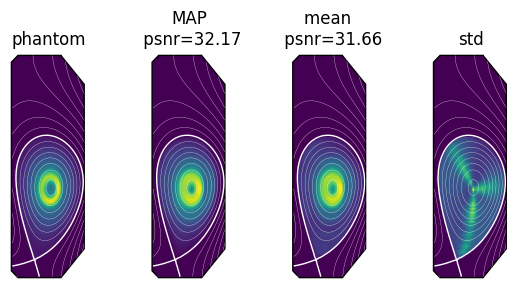

In [7]:
idx_to_be_plotted =5

noise_levels=[0.05,0.25,0.5]
noise_idx=1
noise_=str(noise_levels[noise_idx])
res=results_procedureTrue[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_sxr_" + noise_ + "_true.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_sxr_" + noise_ + "_true.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_sxr_" + noise_ + "_true.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

## DMPX results

In [9]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.1, 0.5, 1.0]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_dmpx_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_dmpx_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics for the first noise-level entry (0.05)

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.1
MSE (MAP): 0.000435 +- 0.0004
SSIM (MAP): 0.965926 +- 0.0196
PSNR (MAP): 34.753673 +- 3.3928
MSE (Mean): 0.000455 +- 0.0004
SSIM (Mean): 0.972372 +- 0.0168
PSNR (Mean): 34.635667 +- 3.5841
Noise level: 0.5
MSE (MAP): 0.000501 +- 0.0004
SSIM (MAP): 0.954767 +- 0.0251
PSNR (MAP): 33.956944 +- 3.1148
MSE (Mean): 0.000497 +- 0.0004
SSIM (Mean): 0.965884 +- 0.0217
PSNR (Mean): 34.003245 +- 3.2021
Noise level: 1.0
MSE (MAP): 0.000725 +- 0.0006
SSIM (MAP): 0.941535 +- 0.0314
PSNR (MAP): 32.403382 +- 3.2486
MSE (Mean): 0.000765 +- 0.0006
SSIM (Mean): 0.952542 +- 0.0297
PSNR (Mean): 32.120214 +- 3.2454


Noise level: 0.1, procedure=True
MSE (MAP): 163.121564 +- 234.3234
SSIM (MAP): 0.963125 +- 0.0207
PSNR (MAP): 34.113354 +- 3.5006
MSE (Mean): 171.758670 +- 247.1923
SSIM (Mean): 0.968980 +- 0.0185
PSNR (Mean): 33.943343 +- 3.6301
Noise level: 0.5, procedure=True
MSE (MAP): 176.838453 +- 236.0252
SSIM (MAP): 0.953728 +- 0.0255
PSNR (MAP): 33.466032 +- 2.9890
MSE (Mean): 170.6770

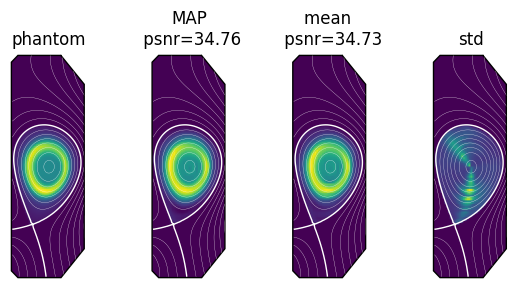

In [10]:
idx_to_be_plotted = 4
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_dmpx_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

## Pilatus results

In [11]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.07, 0.35, 0.7]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.07
MSE (MAP): 0.002727 +- 0.0029
SSIM (MAP): 0.919059 +- 0.0504
PSNR (MAP): 27.511294 +- 4.2120
MSE (Mean): 0.003233 +- 0.0028
SSIM (Mean): 0.911890 +- 0.0522
PSNR (Mean): 26.082298 +- 3.4023
Noise level: 0.35
MSE (MAP): 0.001942 +- 0.0022
SSIM (MAP): 0.922481 +- 0.0471
PSNR (MAP): 29.119100 +- 4.2842
MSE (Mean): 0.002540 +- 0.0022
SSIM (Mean): 0.915455 +- 0.0537
PSNR (Mean): 27.299499 +- 3.7594
Noise level: 0.7
MSE (MAP): 0.002179 +- 0.0023
SSIM (MAP): 0.908735 +- 0.0507
PSNR (MAP): 28.421985 +- 4.1140
MSE (Mean): 0.002972 +- 0.0024
SSIM (Mean): 0.898799 +- 0.0598
PSNR (Mean): 26.445692 +- 3.5512


Noise level: 0.07, procedure=True
MSE (MAP): 1098.825885 +- 1883.3417
SSIM (MAP): 0.908129 +- 0.0595
PSNR (MAP): 26.658847 +- 4.3566
MSE (Mean): 1253.490067 +- 1907.0793
SSIM (Mean): 0.903212 +- 0.0585
PSNR (Mean): 25.497578 +- 3.6137
Noise level: 0.35, procedure=True
MSE (MAP): 725.775876 +- 1302.9539
SSIM (MAP): 0.919599 +- 0.0503
PSNR (MAP): 28.531133 +- 4.3025
MSE (Mean):

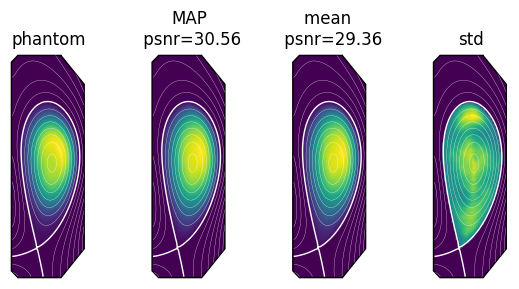

In [12]:
idx_to_be_plotted = 150
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

Estimated anisotropic parameter 0.2154434690031882
Estimated anisotropic parameter 0.0215443469003188
Estimated anisotropic parameter 0.0046415888336127


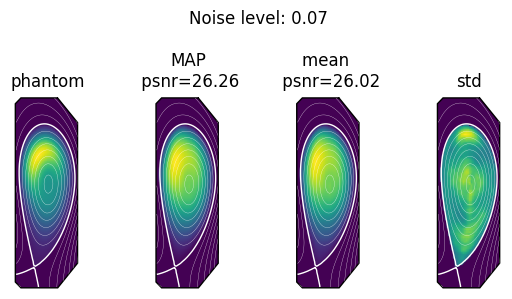

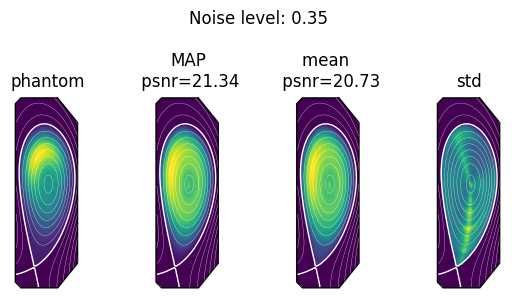

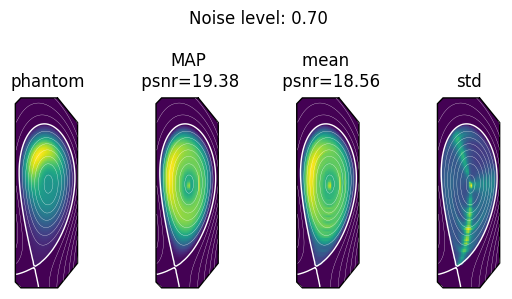

In [13]:
idx_to_be_plotted = 35  # see e.g. 1,4,10 for example of weird behavior
 
for noise_idx in range(3):
    noise_=str(noise_levels[noise_idx])
    res=results[noise_idx]
    means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
    maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
    samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
    ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
    psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
    # plot using show_samples

    summary = torch.stack([
            torch.from_numpy(ground_truth).view(1,1,H,W),
            torch.from_numpy(maps).view(1,1,H,W),
            torch.from_numpy(means).view(1,1,H,W),
            torch.from_numpy(stds).view(1,1,H,W)
    ])
    show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f}".format(res['psnr_map'][idx_to_be_plotted]),
                                "mean \n psnr={:.2f}".format(res['psnr_mean'][idx_to_be_plotted]),
                                "std"],
                                 title="Noise level: {:.2f}".format(noise_levels[noise_idx]), contour_images=[psi,psi,psi,psi])
    print("Estimated anisotropic parameter", res['best_anis_param'][idx_to_be_plotted])

In [14]:
res['best_anis_param'][:25][0]

np.float64(0.0046415888336127)

## Pilatus new hyperparameter tuning

In [15]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"

noise_levels = [0.07, 0.35, 0.7]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rd_alpha_by_camera_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rd_alpha_by_camera_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name} not found.")

# Average metrics

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.07
MSE (MAP): 0.001870 +- 0.0024
SSIM (MAP): 0.928058 +- 0.0464
PSNR (MAP): 29.920024 +- 4.9154
MSE (Mean): 0.002923 +- 0.0023
SSIM (Mean): 0.905248 +- 0.0548
PSNR (Mean): 26.428509 +- 3.3642
Noise level: 0.35
MSE (MAP): 0.002027 +- 0.0024
SSIM (MAP): 0.917794 +- 0.0488
PSNR (MAP): 29.195931 +- 4.5289
MSE (Mean): 0.002736 +- 0.0024
SSIM (Mean): 0.908040 +- 0.0555
PSNR (Mean): 26.972460 +- 3.7439
Noise level: 0.7
MSE (MAP): 0.002254 +- 0.0025
SSIM (MAP): 0.906355 +- 0.0503
PSNR (MAP): 28.339836 +- 4.1587
MSE (Mean): 0.003082 +- 0.0025
SSIM (Mean): 0.895611 +- 0.0598
PSNR (Mean): 26.246467 +- 3.4822


Noise level: 0.07, procedure=True
MSE (MAP): 600.446490 +- 1067.8403
SSIM (MAP): 0.927235 +- 0.0468
PSNR (MAP): 29.838747 +- 4.8544
MSE (Mean): 1112.755333 +- 1597.6190
SSIM (Mean): 0.896208 +- 0.0631
PSNR (Mean): 25.955804 +- 3.6254
Noise level: 0.35, procedure=True
MSE (MAP): 652.013035 +- 1097.5674
SSIM (MAP): 0.917194 +- 0.0494
PSNR (MAP): 29.087798 +- 4.4624
MSE (Mean): 

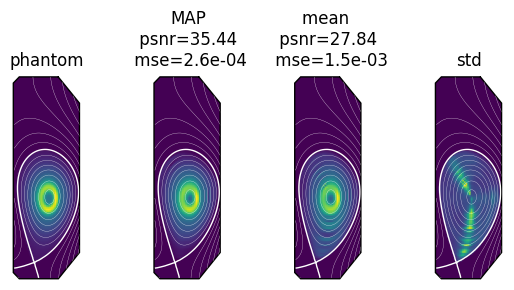

In [ ]:
idx_to_be_plotted = 5 # check 3 or 5 or 7 for ULA vs MAP discrepancies
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(res['psnr_map'][idx_to_be_plotted], res['mse_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(res['psnr_mean'][idx_to_be_plotted], res['mse_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])

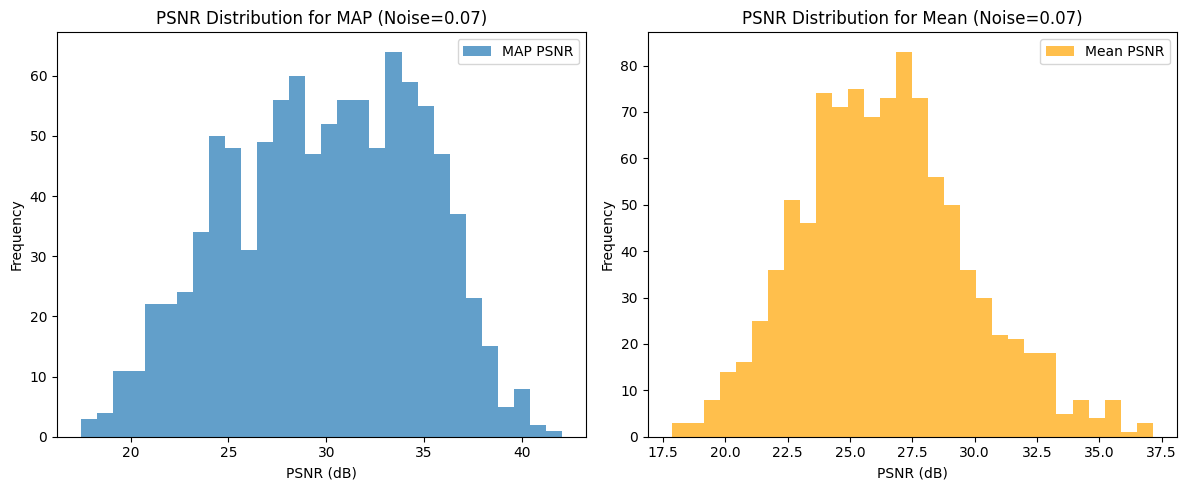

In [ ]:
# plot two side by side histograms with the psnr distribution of map and mean for the noise level 0
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx] 
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(res['psnr_map'], bins=30, alpha=0.7, label='MAP PSNR')
plt.xlabel('PSNR (dB)') 
plt.ylabel('Frequency')
plt.title(f'PSNR Distribution for MAP (Noise={noise_})')
plt.legend()    
plt.subplot(1,2,2)
plt.hist(res['psnr_mean'], bins=30, alpha=0.7, label='Mean PSNR', color='orange')
plt.xlabel('PSNR (dB)')
plt.ylabel('Frequency')
plt.title(f'PSNR Distribution for Mean (Noise={noise_})')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
noise_realization = np.load(f"noise_realizations_pilatus.npy")[idx_to_be_plotted]
fwd_model = np.load("/home/fusiontomo/Repos/diffusion_tomography/forward_model/pilatus_geometry_matrix.npy")
fwd_model /= fwd_model.max()
y_tomo_clean = ground_truth.reshape(-1, H * W) @ fwd_model.T  # (1, n_channels)
sigma_y_tomo = 0.07
noisy_data = y_tomo_clean.flatten() + sigma_y_tomo * noise_realization.flatten()
trim_vals    = np.load(samples_dir / "trimming_values.npy")[idx_to_be_plotted]


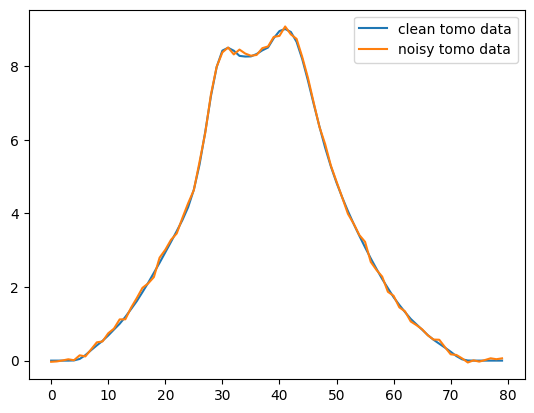

In [ ]:
plt.plot(y_tomo_clean.flatten(), label="clean tomo data")
plt.plot(noisy_data, label="noisy tomo data")
plt.legend()    

In [ ]:
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.hyperparameter_tuning as hyper_tune
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp

mask_core = tomo_helps.define_core_mask(
                    psi=psi, dim_shape=(H,W), trim_values_x=trim_vals
                )

# ------------------------------------------------------------------
# Define functionals with noisy tomo data
# ------------------------------------------------------------------
f, g = fct_def.define_loglikelihoodfromdata_and_logprior(
    noisy_tomo_data=noisy_data.reshape(1, -1),
    psi=psi,
    fwd_matrix=sp.csr_matrix(fwd_model),
    reconstruction_shape=(1, H, W),
    sigma_err=sigma_y_tomo,
    reg_fct_type="anisotropic",
    alpha=ccs['best_anis_param'][idx_to_be_plotted],
    sampling=0.0125
)



In [ ]:
csv_anis_params = pd.read_csv(f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rd_alpha_by_camera_0.07_false.csv")
vvs=csv_anis_params['best_anis_param'][:50]
vvs[[idx_to_be_plotted]]

5    0.001
Name: best_anis_param, dtype: float64

In [ ]:
uq_data = bcomp.run_ula(
                    f, g, 1e-1, psi, trim_vals,
                    with_pos_constraint=True,
                    clip_iterations="core",
                    compute_stats_wrt_MAP=True,
                    estimate_quantiles=False,
                    estimate_tomo_data_stats=False,
                    estimate_peak_location=False,
                    burn_in = int(1e4),
                    samples=int(5e5),
                )

Running 500000 ULA iterations


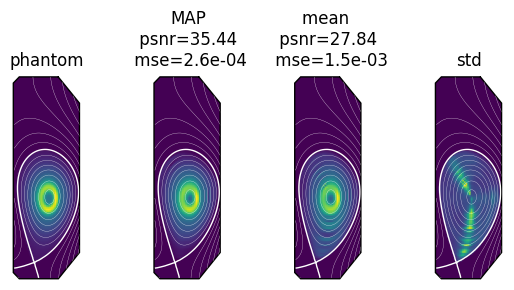

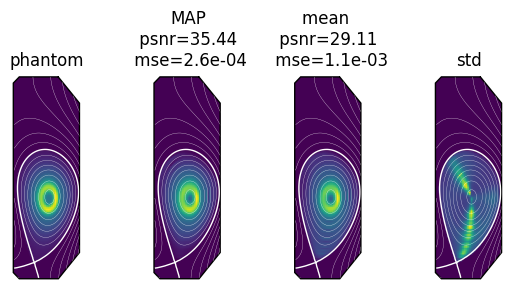

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

idx_to_be_plotted = 5 # check 3 or 5 or 7 for ULA vs MAP discrepancies
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(res['psnr_map'][idx_to_be_plotted], res['mse_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(res['psnr_mean'][idx_to_be_plotted], res['mse_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])
plt.show()


summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(uq_data["im_MAP"]).view(1,1,H,W),
        torch.from_numpy(uq_data["mean"]).view(1,1,H,W),
        torch.from_numpy(np.sqrt(uq_data["var"])).view(1,1,H,W)
])
# compute mse and psnr for uq_data["im_MAP"] and uq_data["mean"]
data_range = float(ground_truth.max() - ground_truth.min())
mse_map, psnr_map = float(((uq_data["im_MAP"] - ground_truth) ** 2).mean()), float(psnr(ground_truth, uq_data["im_MAP"], data_range=data_range))
mse_mean, psnr_mean = float(((uq_data["mean"] - ground_truth) ** 2).mean()), float(psnr(ground_truth, uq_data["mean"], data_range=data_range))
show_samples(summary, titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(psnr_map, mse_map),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(psnr_mean, mse_mean),
                              "std"], contour_images=[psi,psi,psi,psi])
plt.show()

In [ ]:
sigma_y_tomo=0.07
proc_str="false"
csv_anis_params = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rd_alpha_by_camera_{sigma_y_tomo}_{proc_str}.csv"

phantom_indices=np.arange(100,150)

df = pd.read_csv(csv_anis_params)
anis_params = df['best_anis_param'][phantom_indices].values

print(anis_params.shape)

print(anis_params[0])



(50,)
0.0215443469003188


In [ ]:
6*10*50/60

50.0

In [ ]:
import numpy as np
import os
import copy
import time
import sys
import pyxu.operator as pyxop
from pyxu.experimental.sampler._sampler import ULA
from pyxu.experimental.sampler.statistics import OnlineMoment, OnlineVariance

from reaction_diffusion.routines.tomo_fusion.reg_param_est import ProxFuncMoreau

import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def

def run_ula_checkpoints(burn_in,samples, writeback_checkpoints):

    # define ula objective function
    ula_obj = f + 1e-1 * g
    pos_constraint = pyxop.PositiveOrthant(dim_shape=f.dim_shape) 
    ula_obj += ProxFuncMoreau(pos_constraint, mu=1e-3)
    clipping_mask = mask_core
    # initialize ULA sampler
    gamma = 0.98 / ula_obj.diff_lipschitz
    print(ula_obj.diff_lipschitz, gamma)
    ula = ULA(f=ula_obj, gamma=gamma)
    x0 = np.zeros(ula_obj.dim_shape[1:])
    rng = np.random.default_rng(seed=idx_to_be_plotted)
    gen_ula = ula.samples(x0=x0, rng=rng)
    # moments wrt mean
    mean_ula = OnlineMoment(order=1)
    var_ula = OnlineVariance()
    ula_obj_values = np.zeros(int((samples+burn_in)/10), dtype=np.float16)

    # Run ULA
    print("Running {} ULA iterations".format(samples))

    # initialize data
    data = {}
    if 'Anis' in g._name:
        data["alpha"] = g.diffusion_coefficient.alpha
    # start timer
    start_time = time.time()

    # perform burn in iterations
    for i in range(burn_in):
        sample = next(gen_ula)
        if clipping_mask is not None:
            ula.x = clipping_mask * sample
        if i % 10 == 0:
            ula_obj_values[int(i/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)

    for i in range(samples):
        sample = next(gen_ula)
        if clipping_mask is not None:
            ula.x = clipping_mask * sample

        if (i+1) % int(1e5) == 0:
            print("iteration ", i+1)

        # update central moments
        mean, var = mean_ula.update(sample), var_ula.update(sample)
        if i % 10 == 0:
            ula_obj_values[int(i/10 + burn_in/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)

        if (i+1) in writeback_checkpoints:
            data["mean_"+str(i+1)], data["var_"+str(i+1)] = copy.deepcopy(mean), copy.deepcopy(var)
            data["time_"+str(i+1)] = time.time() - start_time

    data["ula_obj_values"] = ula_obj_values

    return data

In [ ]:
def run_ula_checkpoints_new(f, g, reg_param,
            psi, trim_values_x,
            with_pos_constraint=False,
            clip_iterations=None, clipping_mask=None,
            samples=int(1e5), burn_in=int(1e3), thinning_factor=1,
            seed=0, show_progress=False, writeback_checkpoints=None):
    # define ula objective function
    ula_obj = f + reg_param * g
    pos_constraint = pyxop.PositiveOrthant(dim_shape=f.dim_shape) if with_pos_constraint else None
    if with_pos_constraint:
        # add positivity constraint to ula objective function
        ula_obj += ProxFuncMoreau(pos_constraint, mu=1e-3)
    # define tcv and core masks
    mask_tcv = tomo_helps.define_tcv_mask(dim_shape=ula_obj.dim_shape[1:])
    mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=ula_obj.dim_shape[1:], trim_values_x=trim_values_x)
    if clipping_mask is not None:
        clipping_mask = clipping_mask
    else:
        if clip_iterations == "core":
            clipping_mask = mask_core
        elif clip_iterations == "tcv":
            clipping_mask = mask_tcv
    # initialize ULA sampler
    gamma = 0.98 / ula_obj.diff_lipschitz
    ula = ULA(f=ula_obj, gamma=gamma)
    x0 = np.zeros(ula_obj.dim_shape[1:])
    rng = np.random.default_rng(seed=seed)
    gen_ula = ula.samples(x0=x0, rng=rng)
    # moments wrt mean
    mean_ula = OnlineMoment(order=1)
    var_ula = OnlineVariance()
    ula_obj_values = np.zeros(int((samples+burn_in)/10), dtype=np.float16)

    # Run ULA
    print("Running {} ULA iterations".format(samples))

    # initialize data
    data = {}
    data["reg_param"], data["sampling"] = reg_param, g.sampling
    if 'Anis' in g._name:
        data["alpha"] = g.diffusion_coefficient.alpha
    data["with_pos_constraint"], data["clip_iterations"] = with_pos_constraint, clip_iterations
    data["samples"], data["burn_in"], data["thinning_factor"] = samples, burn_in, thinning_factor

    for i in range(burn_in):
        # Burn-in phase
        sample = next(gen_ula)
        if clipping_mask is not None:
            ula.x = clipping_mask * sample
        if i % 10 == 0:
            ula_obj_values[int(i/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)

    for i in range(samples):
        sample = next(gen_ula)
        if clipping_mask is not None:
            ula.x = clipping_mask * sample

        if show_progress and (i+1) % int(1e5) == 0:
            print("iteration ", i+1)

        if i % thinning_factor == 0:
            # update central moments
            mean, var = mean_ula.update(sample), var_ula.update(sample)
            
        if i % 10 == 0:
            ula_obj_values[int(i/10 + burn_in/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)

        if (i+1) in writeback_checkpoints:
            data["mean_"+str(i+1)], data["var_"+str(i+1)] = copy.deepcopy(mean), copy.deepcopy(var)
    # store data
    data["mean"], data["var"] = mean, var
    data["ula_obj_values"] = ula_obj_values

    return data

In [ ]:
uq_data = bcomp.run_ula(
                    f, g, 1e-1, psi, trim_vals,
                    with_pos_constraint=True,
                    clip_iterations="core",
                    compute_stats_wrt_MAP=True,
                    estimate_quantiles=False,
                    estimate_tomo_data_stats=False,
                    estimate_peak_location=False,
                    burn_in = int(1e4),
                    samples=int(5e5),
                )

In [ ]:
writeback_checkpoints=np.array([int(1e1), int(2.5e1), int(5e1), int(7.5e1),
                                                        int(1e2), int(2.5e2), int(5e2), int(7.5e2),
                                                        int(1e3), int(2.5e3), int(5e3), int(7.5e3),
                                                        int(1e4),int(2.5e4), int(5e4), int(7.5e4),
                                                        int(1e5),int(2.5e5), int(5e5), int(7.5e5),
                                                        int(1e6),int(2.5e6), int(5e6), int(7.5e6),
                                                        int(1e7)])

data = run_ula_checkpoints_new(f, g, 1e-1,
            psi, trim_vals,
            with_pos_constraint=True,
            clip_iterations="core",
            samples=int(5e6), burn_in=int(1e5), thinning_factor=1,
            seed=0, show_progress=True, writeback_checkpoints=writeback_checkpoints)

Running 5000000 ULA iterations


/tmp/ipykernel_1669994/3836353633.py:51: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ula_obj_values[int(i/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)
/tmp/ipykernel_1669994/3836353633.py:66: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ula_obj_values[int(i/10 + burn_in/10)] = float(f(sample) + 1e-1 * np.sum(g.grad(sample) * sample) / 2)


iteration  100000
iteration  200000
iteration  300000
iteration  400000
iteration  500000
iteration  600000
iteration  700000
iteration  800000
iteration  900000
iteration  1000000
iteration  1100000
iteration  1200000
iteration  1300000
iteration  1400000
iteration  1500000
iteration  1600000
iteration  1700000
iteration  1800000
iteration  1900000
iteration  2000000
iteration  2100000
iteration  2200000
iteration  2300000
iteration  2400000
iteration  2500000
iteration  2600000
iteration  2700000
iteration  2800000
iteration  2900000
iteration  3000000
iteration  3100000
iteration  3200000
iteration  3300000
iteration  3400000
iteration  3500000
iteration  3600000
iteration  3700000
iteration  3800000
iteration  3900000
iteration  4000000
iteration  4100000
iteration  4200000
iteration  4300000
iteration  4400000
iteration  4500000
iteration  4600000
iteration  4700000
iteration  4800000
iteration  4900000
iteration  5000000


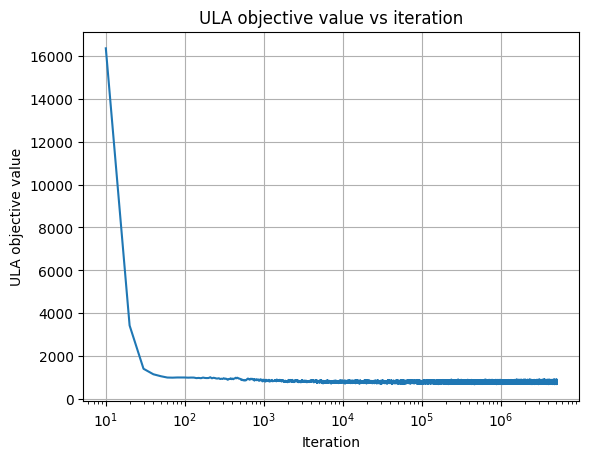

In [ ]:
tbp = data["ula_obj_values"]
idxs_tbp = np.arange(0, len(tbp)) * 10 + 10
plt.plot(idxs_tbp, tbp)
plt.xscale("log")
plt.xlabel("Iteration")
plt.ylabel("ULA objective value")
plt.title("ULA objective value vs iteration")
plt.grid()
plt.show()

In [ ]:
print(float(f(ground_truth) + 1e-1 * np.sum(g.grad(ground_truth) * ground_truth) / 2))
print(float(f(uq_data["im_MAP"]) + 1e-1 * np.sum(g.grad(uq_data["im_MAP"]) * uq_data["im_MAP"]) / 2))
print(float(f(uq_data["mean"]) + 1e-1 * np.sum(g.grad(uq_data["mean"]) * uq_data["mean"]) / 2))

59.024780159281406
27.62363034206672
33.01229378964126


/tmp/ipykernel_1669994/2188807078.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(f(ground_truth) + 1e-1 * np.sum(g.grad(ground_truth) * ground_truth) / 2))
/tmp/ipykernel_1669994/2188807078.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(f(uq_data["im_MAP"]) + 1e-1 * np.sum(g.grad(uq_data["im_MAP"]) * uq_data["im_MAP"]) / 2))
/tmp/ipykernel_1669994/2188807078.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(f(uq_data[

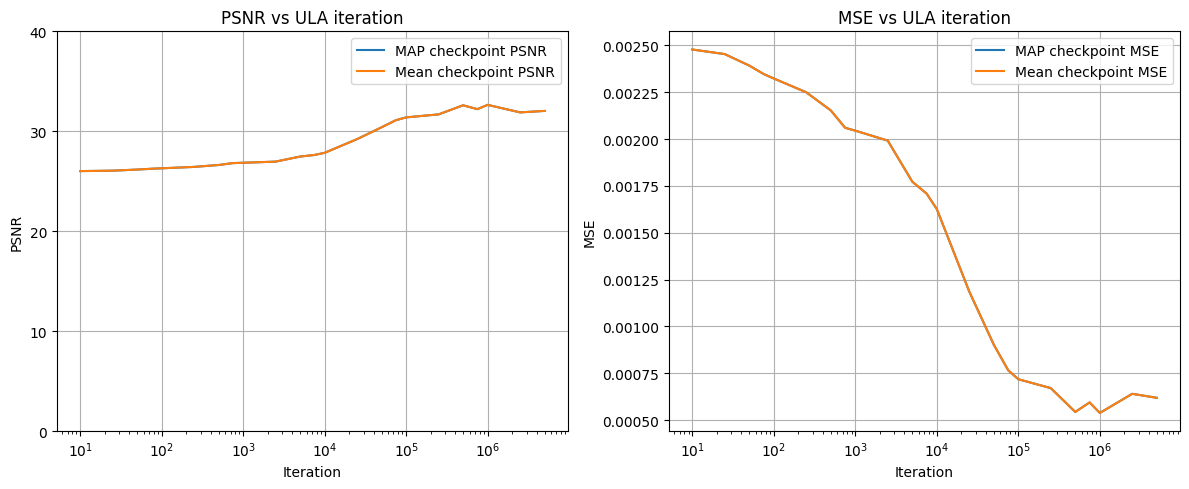

In [ ]:
# compute psnr and mse for the checkpoints and plot them
from skimage.metrics import peak_signal_noise_ratio as psnr
checkpoints = writeback_checkpoints
psnr_map_checkpoints = []
mse_map_checkpoints = []
psnr_mean_checkpoints = []
mse_mean_checkpoints = []
for cp in checkpoints[:23]:  # only plot the first 23 checkpoints for better visibility
    mean_cp = data["mean_"+str(cp)]
    var_cp = data["var_"+str(cp)]
    psnr_map_cp = psnr(ground_truth, data["mean_"+str(cp)].squeeze(), data_range=data_range)
    mse_map_cp = ((data["mean_"+str(cp)].squeeze() - ground_truth) ** 2).mean()
    psnr_mean_cp = psnr(ground_truth, data["mean_"+str(cp)].squeeze(), data_range=data_range)
    mse_mean_cp = ((data["mean_"+str(cp)].squeeze() - ground_truth) ** 2).mean()
    psnr_map_checkpoints.append(psnr_map_cp)
    mse_map_checkpoints.append(mse_map_cp)
    psnr_mean_checkpoints.append(psnr_mean_cp)
    mse_mean_checkpoints.append(mse_mean_cp)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(checkpoints[:23], psnr_map_checkpoints, label="MAP checkpoint PSNR")
plt.plot(checkpoints[:23], psnr_mean_checkpoints, label="Mean checkpoint PSNR")
plt.xscale("log")
plt.yticks([0, 10, 20, 30, 40])
plt.xlabel("Iteration")
plt.ylabel("PSNR")
plt.title("PSNR vs ULA iteration")
plt.legend()
plt.grid()
plt.subplot(1, 2, 2)
plt.plot(checkpoints[:23], mse_map_checkpoints, label="MAP checkpoint MSE")
plt.plot(checkpoints[:23], mse_mean_checkpoints, label="Mean checkpoint MSE")
plt.xscale("log")
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("MSE vs ULA iteration")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

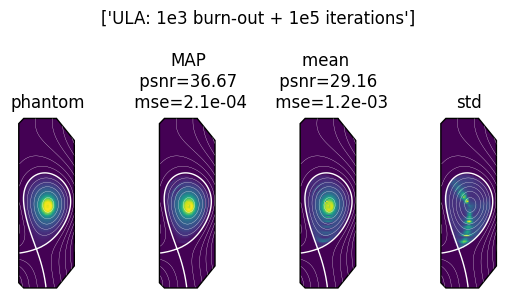

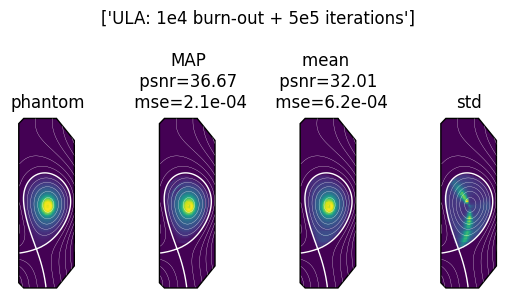

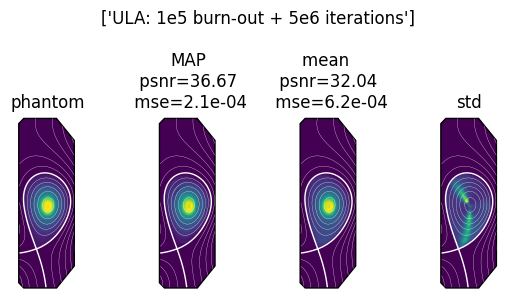

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr

idx_to_be_plotted = 7 # check 3 or 5 or 7 for ULA vs MAP discrepancies
noise_idx=0
noise_=str(noise_levels[noise_idx])
res=results[noise_idx]
means,stds = np.load("metrics_csv_phantom_analysis_rd/post_means_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:], np.load("metrics_csv_phantom_analysis_rd/post_stds_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]
maps = np.load("metrics_csv_phantom_analysis_rd/maps_pilatus_rd_alpha_by_camera_" + noise_ + "_false.npy")[idx_to_be_plotted,:]

samples_dir  = Path("/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples")
ground_truth = np.load(samples_dir / "sxr_samples_with_background_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
psi         = np.load(samples_dir / "psis_coarse.npy")[idx_to_be_plotted]  # (1000, H, W)
# plot using show_samples

summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(maps).view(1,1,H,W),
        torch.from_numpy(means).view(1,1,H,W),
        torch.from_numpy(stds).view(1,1,H,W)
])
show_samples(summary, title=["ULA: 1e3 burn-out + 1e5 iterations"],
             titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(res['psnr_map'][idx_to_be_plotted], res['mse_map'][idx_to_be_plotted]),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(res['psnr_mean'][idx_to_be_plotted], res['mse_mean'][idx_to_be_plotted]),
                              "std"], contour_images=[psi,psi,psi,psi])
plt.show()


summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(uq_data["im_MAP"]).view(1,1,H,W),
        torch.from_numpy(uq_data["mean"]).view(1,1,H,W),
        torch.from_numpy(np.sqrt(uq_data["var"])).view(1,1,H,W)
])
# compute mse and psnr for uq_data["im_MAP"] and uq_data["mean"]
data_range = float(ground_truth.max() - ground_truth.min())
mse_map, psnr_map = float(((uq_data["im_MAP"] - ground_truth) ** 2).mean()), float(psnr(ground_truth, uq_data["im_MAP"], data_range=data_range))
mse_mean, psnr_mean = float(((uq_data["mean"] - ground_truth) ** 2).mean()), float(psnr(ground_truth, uq_data["mean"], data_range=data_range))
show_samples(summary, title=["ULA: 1e4 burn-out + 5e5 iterations"],
             titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(psnr_map, mse_map),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(psnr_mean, mse_mean),
                              "std"], contour_images=[psi,psi,psi,psi])
plt.show()


summary = torch.stack([
        torch.from_numpy(ground_truth).view(1,1,H,W),
        torch.from_numpy(uq_data["im_MAP"]).view(1,1,H,W),
        torch.from_numpy(data["mean_5000000"].squeeze()).view(1,1,H,W),
        torch.from_numpy(np.sqrt(data["var_5000000"])).view(1,1,H,W)
])
# compute mse and psnr for uq_data["im_MAP"] and uq_data["mean"]
data_range = float(ground_truth.max() - ground_truth.min())
mse_map, psnr_map = float(((uq_data["im_MAP"] - ground_truth) ** 2).mean()), float(psnr(ground_truth, uq_data["im_MAP"], data_range=data_range))
mse_mean, psnr_mean = float(((data["mean_5000000"].squeeze() - ground_truth) ** 2).mean()), float(psnr(ground_truth, data["mean_5000000"].squeeze(), data_range=data_range))
show_samples(summary, title=["ULA: 1e5 burn-out + 5e6 iterations"],
             titles=["phantom", "MAP\n psnr={:.2f} \n mse={:.1e}".format(psnr_map, mse_map),
                              "mean \n psnr={:.2f} \n mse={:.1e}".format(psnr_mean, mse_mean),
                              "std"], contour_images=[psi,psi,psi,psi])
plt.show()

## Pilatus correct hyperparams + more ULA samples

In [ ]:
# check sxr phantom analysis results
#csv_name = f"metrics_diffusion_sxr_{sigma_y_tomo}_zeta{zeta}_lambda{lambda_}.csv"
import os

noise_levels = [0.07, 0.35, 0.7]

results = []
results_procedureTrue = []
for noise in noise_levels:
    csv_name = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rdcorrect_ula1e6_{noise}_false.csv"
    csv_name_procedureTrue = f"metrics_csv_phantom_analysis_rd/metrics_rd_pilatus_rdcorrect_ula1e6_{noise}_true.csv"
    if os.path.exists(csv_name):
        df = pd.read_csv(csv_name)
        df["noise"] = noise
        results.append(df)
    else:
        print(f"File {csv_name} not found.")
    if os.path.exists(csv_name_procedureTrue):
        df = pd.read_csv(csv_name_procedureTrue)
        df["noise"] = noise
        results_procedureTrue.append(df)
    else:
        print(f"File {csv_name_procedureTrue} not found.")

# Average metrics

for i in range(len(results)):
    print(f"Noise level: {results[i]['noise'].iloc[0]}")

    df_noise = results[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

print('\n')

for i in range(len(results_procedureTrue)):
    print(f"Noise level: {results_procedureTrue[i]['noise'].iloc[0]}, procedure=True")

    df_noise = results_procedureTrue[i]  # corresponds to the current noise level

    metrics = ["mse_map", "ssim_map", "psnr_map", "mse_mean", "ssim_mean", "psnr_mean"]
    metric_labels = {"mse_map": "MSE (MAP)", "ssim_map": "SSIM (MAP)", "psnr_map": "PSNR (MAP)", "mse_mean": "MSE (Mean)", "ssim_mean": "SSIM (Mean)", "psnr_mean": "PSNR (Mean)"}
    avg_vals = df_noise[metrics].mean()

    for m in metrics:
        print(f"{metric_labels[m]}: {avg_vals[m]:.6f} +- {df_noise[m].std():.4f}")

Noise level: 0.07
MSE (MAP): 0.001870 +- 0.0024
SSIM (MAP): 0.928058 +- 0.0464
PSNR (MAP): 29.920024 +- 4.9154
MSE (Mean): 0.002373 +- 0.0023
SSIM (Mean): 0.923698 +- 0.0509
PSNR (Mean): 27.957827 +- 4.1973
Noise level: 0.35
MSE (MAP): 0.001942 +- 0.0022
SSIM (MAP): 0.922481 +- 0.0471
PSNR (MAP): 29.119100 +- 4.2842
MSE (Mean): 0.002356 +- 0.0022
SSIM (Mean): 0.922066 +- 0.0516
PSNR (Mean): 27.825301 +- 3.9988
Noise level: 0.7
MSE (MAP): 0.002179 +- 0.0023
SSIM (MAP): 0.908735 +- 0.0507
PSNR (MAP): 28.421985 +- 4.1140
MSE (Mean): 0.002717 +- 0.0024
SSIM (Mean): 0.907598 +- 0.0576
PSNR (Mean): 27.053480 +- 3.8533


Noise level: 0.07, procedure=True
MSE (MAP): 600.446490 +- 1067.8403
SSIM (MAP): 0.927235 +- 0.0468
PSNR (MAP): 29.838747 +- 4.8544
MSE (Mean): 810.432383 +- 1255.9159
SSIM (Mean): 0.921138 +- 0.0541
PSNR (Mean): 27.843269 +- 4.3764
Noise level: 0.35, procedure=True
MSE (MAP): 725.775876 +- 1302.9539
SSIM (MAP): 0.919599 +- 0.0503
PSNR (MAP): 28.531133 +- 4.3025
MSE (Mean): 8